# Protein Binder Association Analysis: Binding Strength & Sequence Properties

## Analysis Goals

This notebook performs **exploratory analysis** rather than pure prediction:

1. **Per-Target Analysis**: Different targets may have different binding characteristics
2. **Binding Strength**: Analyze continuous KD values (not just binary binding)
3. **Feature Associations**: Which computational features associate with binding?
4. **Sequence Properties**: Length, composition, isoelectric point, molecular weight
5. **Lasso Regression**: Identify important features while preventing overfitting
6. **Target Comparison**: Which targets are easier/harder to predict?

**Key Principle**: Use only COMPUTATIONAL features to understand EXPERIMENTAL outcomes

## 1. Setup and Imports

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, pearsonr

from sklearn.linear_model import Lasso, LassoCV, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from src.utils.data_loader import ProteinDataLoader

# Set style
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ Imports successful")

✓ Imports successful


## 2. Load and Parse Data by Target

In [2]:
# Load data
data_path = '../proteinbase_all_data_28_01_2026.csv'
loader = ProteinDataLoader(data_path)
loader.load_data()

# Get computational and experimental features
computational_df = loader.get_computational_features()
experimental_df = loader.get_experimental_features()

print(f"Total samples: {len(computational_df)}")
print(f"Computational features: {len(computational_df.columns)}")
print(f"Experimental features: {len(experimental_df.columns)}")

Loading data from ../proteinbase_all_data_28_01_2026.csv...
Loaded 5253 protein designs
Extracting COMPUTATIONAL features only (preventing data leakage)...
Extracted 84 computational features
Total columns (including metadata): 98
Extracting EXPERIMENTAL features only...
Extracted 114 experimental feature columns
Total samples: 5253
Computational features: 98
Experimental features: 114


## 3. Extract Target-Specific Binding Data

In [3]:
# Extract target-specific KD values and binding outcomes
import json

def extract_target_binding_data(row):
    """Extract binding data organized by target."""
    try:
        evaluations = json.loads(row['evaluations']) if isinstance(row['evaluations'], str) else []
    except:
        evaluations = []
    
    target_data = {}
    
    for eval_item in evaluations:
        if eval_item.get('type') != 'experimental':
            continue
        
        target = eval_item.get('target', 'unknown')
        metric = eval_item.get('metric', '')
        value = eval_item.get('value')
        
        if target == 'unknown' or target is None:
            continue
        
        if target not in target_data:
            target_data[target] = {}
        
        # Store binding metrics
        if metric == 'kd' and isinstance(value, (int, float)):
            target_data[target]['kd'] = value
            target_data[target]['log_kd'] = np.log10(value) if value > 0 else np.nan
            target_data[target]['pkd'] = -np.log10(value) if value > 0 else np.nan
        elif metric == 'kon' and isinstance(value, (int, float)):
            target_data[target]['kon'] = value
            target_data[target]['log_kon'] = np.log10(value) if value > 0 else np.nan
        elif metric == 'koff' and isinstance(value, (int, float)):
            target_data[target]['koff'] = value
            target_data[target]['log_koff'] = np.log10(value) if value > 0 else np.nan
        elif metric == 'binding' and isinstance(value, bool):
            target_data[target]['binding'] = int(value)
        elif metric == 'binding_strength':
            target_data[target]['binding_strength'] = value
    
    return target_data

# Apply to raw data
raw_data = loader.raw_data.copy()
raw_data['target_binding'] = raw_data.apply(extract_target_binding_data, axis=1)

print("✓ Extracted target-specific binding data")

✓ Extracted target-specific binding data


In [4]:
# Create long-format dataset with one row per protein-target pair
records = []

for idx, row in raw_data.iterrows():
    protein_id = row.get('id', idx)
    sequence = row.get('sequence', '')
    
    for target, metrics in row['target_binding'].items():
        record = {
            'protein_id': protein_id,
            'target': target,
            'sequence': sequence,
            'sequence_length': len(sequence) if isinstance(sequence, str) else 0,
            **metrics  # Add all binding metrics
        }
        records.append(record)

target_df = pd.DataFrame(records)

print(f"\nTarget-level dataset:")
print(f"  Total protein-target pairs: {len(target_df)}")
print(f"  Unique proteins: {target_df['protein_id'].nunique()}")
print(f"  Unique targets: {target_df['target'].nunique()}")
print(f"\nTargets found: {sorted(target_df['target'].unique())}")


Target-level dataset:
  Total protein-target pairs: 2640
  Unique proteins: 2527
  Unique targets: 24

Targets found: ['der21', 'der7', 'egfr', 'fcrn', 'fgf-r1', 'hnmt', 'human-ambp', 'human-gm2a', 'human-idi2', 'human-insulin-receptor', 'human-mzb1-perp1', 'human-orm2', 'human-pdgfr-beta', 'human-phyh', 'human-pmvk', 'human-rfk', 'human-serum-albumin', 'human-tnfa', 'ifnar2', 'il7r', 'mdm2', 'nipah-glycoprotein-g', 'pd-l1', 'spcas9']


In [5]:
# Summary statistics per target
target_summary = target_df.groupby('target').agg({
    'protein_id': 'count',
    'binding': lambda x: x.sum() if 'binding' in target_df.columns else 0,
    'kd': ['count', 'mean', 'median', 'std'],
    'pkd': ['mean', 'median']
}).round(4)

target_summary.columns = ['_'.join(col).strip('_') for col in target_summary.columns]
target_summary = target_summary.sort_values('protein_id_count', ascending=False)

print("\n" + "="*80)
print("TARGET SUMMARY STATISTICS")
print("="*80)
print(target_summary)
print("="*80)


TARGET SUMMARY STATISTICS
                        protein_id_count  binding_<lambda>  kd_count  kd_mean  \
target                                                                          
nipah-glycoprotein-g                1033             103.0       102      0.0   
egfr                                 833             130.0       118      0.0   
human-serum-albumin                  103               0.0         0      NaN   
il7r                                  97              62.0        43      0.0   
pd-l1                                 75              39.0        38      0.0   
human-insulin-receptor                35              21.0        21      0.0   
human-tnfa                            35               0.0         0      NaN   
human-gm2a                            30               0.0         0      NaN   
human-idi2                            30               5.0         5      0.0   
human-ambp                            30               5.0         4      0.0   
h

## 4. Merge with Computational Features

In [6]:
# Merge computational features with target data
# Match by index (protein_id is the index in computational_df)

# First, create a mapping from protein_id to index
id_to_idx = {pid: idx for idx, pid in enumerate(raw_data['id'])}
target_df['data_idx'] = target_df['protein_id'].map(id_to_idx)

# Get numeric computational features
comp_numeric = computational_df.select_dtypes(include=[np.number])

# Merge
analysis_df = target_df.merge(
    comp_numeric,
    left_on='data_idx',
    right_index=True,
    how='left'
)

print(f"\nMerged dataset:")
print(f"  Shape: {analysis_df.shape}")
print(f"  Computational features: {len(comp_numeric.columns)}")
print(f"  Total columns: {len(analysis_df.columns)}")


Merged dataset:
  Shape: (2640, 98)
  Computational features: 84
  Total columns: 98


## 5. Sequence Property Analysis

In [23]:
# Calculate amino acid composition and properties
def analyze_sequence_properties(seq):
    """Calculate sequence composition and properties."""
    if not isinstance(seq, str) or len(seq) == 0:
        return {}
    
    seq = seq.upper()
    length = len(seq)
    
    # Amino acid groups
    hydrophobic = 'AILMFWYV'
    polar = 'STNQ'
    charged_pos = 'KRH'
    charged_neg = 'DE'
    aromatic = 'FWY'
    
    return {
        # 'pct_hydrophobic': sum(seq.count(aa) for aa in hydrophobic) / length * 100,
        # 'pct_polar': sum(seq.count(aa) for aa in polar) / length * 100,
        # 'pct_charged_pos': sum(seq.count(aa) for aa in charged_pos) / length * 100,
        # 'pct_charged_neg': sum(seq.count(aa) for aa in charged_neg) / length * 100,
        # 'pct_aromatic': sum(seq.count(aa) for aa in aromatic) / length * 100,
        # 'net_charge': sum(seq.count(aa) for aa in charged_pos) - sum(seq.count(aa) for aa in charged_neg),
        # 'charge_density': (sum(seq.count(aa) for aa in charged_pos) + sum(seq.count(aa) for aa in charged_neg)) / length * 100
    }

# Apply sequence analysis
seq_props = analysis_df['sequence'].apply(analyze_sequence_properties)
seq_props_df = pd.DataFrame(seq_props.tolist(), index=analysis_df.index)

# Add to analysis dataframe
analysis_df = pd.concat([analysis_df, seq_props_df], axis=1)

print("✓ Added sequence property features:")
print(f"  {list(seq_props_df.columns)}")

✓ Added sequence property features:
  []


In [24]:
# Visualize sequence properties by binding outcome
if 'binding' in analysis_df.columns and analysis_df['binding'].notna().sum() > 0:
    seq_feature_cols = list(seq_props_df.columns)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for idx, col in enumerate(seq_feature_cols):
        if idx >= len(axes):
            break
        
        ax = axes[idx]
        
        # Split by binding
        binders = analysis_df[analysis_df['binding'] == 1][col].dropna()
        non_binders = analysis_df[analysis_df['binding'] == 0][col].dropna()
        
        if len(binders) > 0 and len(non_binders) > 0:
            ax.violinplot([non_binders, binders], positions=[0, 1], 
                         showmeans=True, showmedians=True)
            ax.set_xticks([0, 1])
            ax.set_xticklabels(['Non-binder', 'Binder'])
            ax.set_ylabel(col)
            ax.set_title(col.replace('_', ' ').title())
            ax.grid(alpha=0.3)
            
            # Statistical test
            _, p_value = stats.mannwhitneyu(binders, non_binders, alternative='two-sided')
            ax.text(0.5, ax.get_ylim()[1]*0.95, f'p={p_value:.3e}', 
                   ha='center', fontsize=8, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Remove extra subplots
    for idx in range(len(seq_feature_cols), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.suptitle('Sequence Properties: Binders vs Non-Binders', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../results/sequence_properties_by_binding.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Insufficient binding data for comparison")

<Figure size 1600x800 with 0 Axes>

## 6. Univariate Association Analysis

Identify which computational features correlate with binding strength (KD)

In [25]:
# Correlation analysis for binding strength (pKD)
def compute_correlations(data, target_col, feature_cols, method='spearman'):
    """Compute correlations between features and target."""
    results = []
    
    # Filter to rows with valid target values
    valid_data = data[data[target_col].notna()].copy()
    
    if len(valid_data) < 10:
        print(f"Warning: Only {len(valid_data)} samples with {target_col}")
        return pd.DataFrame()
    
    for feature in feature_cols:
        # Get valid pairs
        valid_pairs = valid_data[[feature, target_col]].dropna()
        
        if len(valid_pairs) < 10:
            continue
        
        x = valid_pairs[feature].values
        y = valid_pairs[target_col].values
        
        # Skip if no variance
        if x.std() == 0 or y.std() == 0:
            continue
        
        # Compute correlation
        if method == 'spearman':
            corr, p_value = spearmanr(x, y)
        else:
            corr, p_value = pearsonr(x, y)
        
        results.append({
            'feature': feature,
            'correlation': corr,
            'abs_correlation': abs(corr),
            'p_value': p_value,
            'n_samples': len(valid_pairs),
            'significant': p_value < 0.05
        })
    
    results_df = pd.DataFrame(results)
    if len(results_df) > 0:
        results_df = results_df.sort_values('abs_correlation', ascending=False)
    
    return results_df

print("Computing univariate correlations with binding strength (pKD)...")

Computing univariate correlations with binding strength (pKD)...


In [26]:
# Get all computational + sequence features
computational_features = [col for col in analysis_df.columns 
                         if col in comp_numeric.columns or col in seq_props_df.columns]

# Analyze correlation with pKD (higher pKD = stronger binding)
if 'pkd' in analysis_df.columns:
    pkd_correlations = compute_correlations(
        analysis_df, 'pkd', computational_features, method='spearman'
    )
    
    print("\n" + "="*80)
    print("TOP 30 FEATURES ASSOCIATED WITH BINDING STRENGTH (pKD)")
    print("="*80)
    print("(Higher pKD = stronger binding = lower KD)")
    print("\nPositive correlation = feature increases with binding strength")
    print("Negative correlation = feature decreases with binding strength")
    print("="*80)
    print(pkd_correlations.head(30).to_string(index=False))
    print("="*80)
else:
    print("No pKD data available")


TOP 30 FEATURES ASSOCIATED WITH BINDING STRENGTH (pKD)
(Higher pKD = stronger binding = lower KD)

Positive correlation = feature increases with binding strength
Negative correlation = feature decreases with binding strength
                                                                  feature  correlation  abs_correlation      p_value  n_samples  significant
                                                seqidentity_computational     0.676642         0.676642 5.912899e-15        102         True
                                  domainmatch_evalue_afdb50_computational    -0.553411         0.553411 2.351477e-09        100         True
                                    domainmatch_rmsd_afdb50_computational    -0.495714         0.495714 1.571427e-07        100         True
                                domainmatch_tm_score_afdb50_computational     0.491173         0.491173 2.118617e-07        100         True
                          domainmatch_aligned_length_afdb50_computati

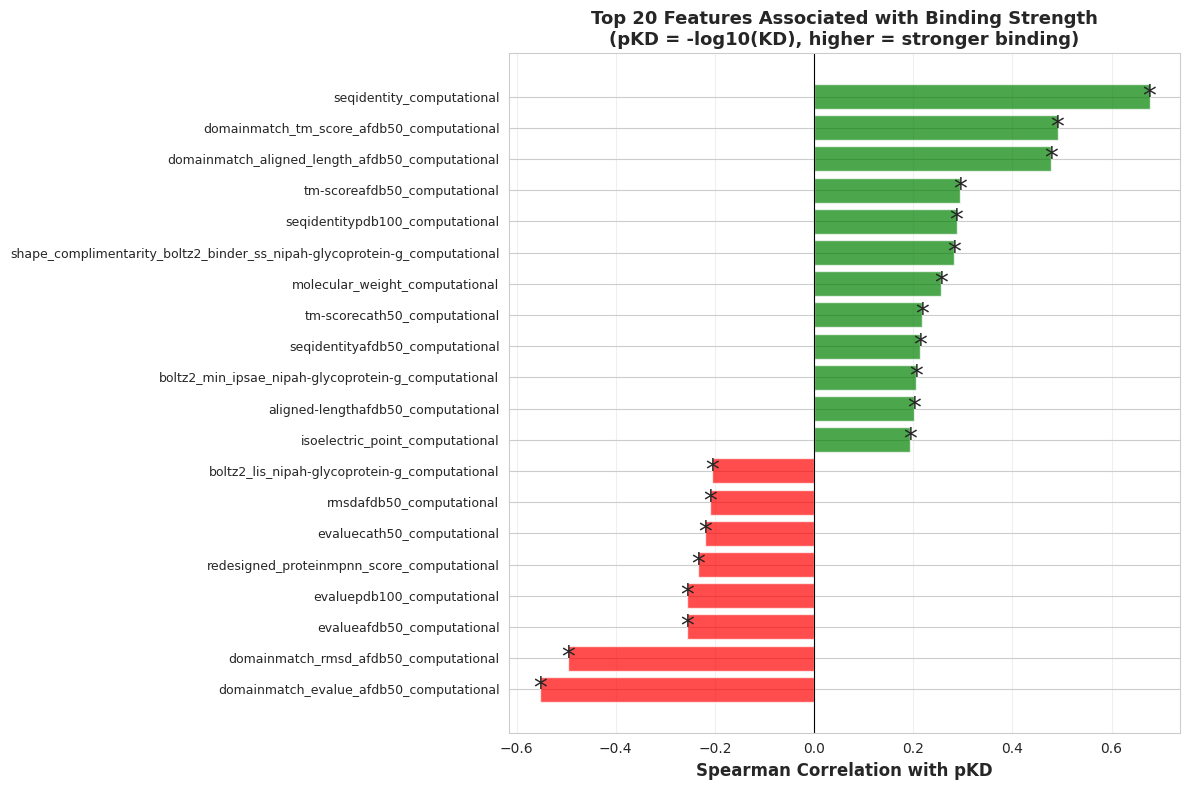

In [27]:
# Visualize top correlations
if 'pkd' in analysis_df.columns and len(pkd_correlations) > 0:
    top_features = pkd_correlations.head(20)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Sort by correlation (not absolute)
    plot_data = top_features.sort_values('correlation')
    
    colors = ['red' if x < 0 else 'green' for x in plot_data['correlation']]
    y_pos = np.arange(len(plot_data))
    
    ax.barh(y_pos, plot_data['correlation'], color=colors, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_data['feature'], fontsize=9)
    ax.set_xlabel('Spearman Correlation with pKD', fontsize=12, fontweight='bold')
    ax.set_title('Top 20 Features Associated with Binding Strength\n(pKD = -log10(KD), higher = stronger binding)', 
                fontsize=13, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.grid(alpha=0.3, axis='x')
    
    # Add significance markers
    for i, (idx, row) in enumerate(plot_data.iterrows()):
        if row['significant']:
            ax.text(row['correlation'], i, '*', fontsize=20, ha='center', va='center')
    
    plt.tight_layout()
    plt.savefig('../results/pkd_correlations_top20.png', dpi=300, bbox_inches='tight')
    plt.show()

## 7. Per-Target Analysis

Different targets may have different predictability

In [28]:
# Analyze each target separately
target_correlation_results = {}

for target in analysis_df['target'].unique():
    target_data = analysis_df[analysis_df['target'] == target]
    
    if 'pkd' in target_data.columns and target_data['pkd'].notna().sum() >= 10:
        corrs = compute_correlations(
            target_data, 'pkd', computational_features, method='spearman'
        )
        target_correlation_results[target] = corrs
        
        print(f"\nTarget: {target}")
        print(f"  Samples with pKD: {target_data['pkd'].notna().sum()}")
        print(f"  Top feature: {corrs.iloc[0]['feature'] if len(corrs) > 0 else 'N/A'}")
        print(f"  Correlation: {corrs.iloc[0]['correlation']:.3f} (p={corrs.iloc[0]['p_value']:.3e})" if len(corrs) > 0 else "")


Target: nipah-glycoprotein-g
  Samples with pKD: 102
  Top feature: seqidentity_computational
  Correlation: 0.677 (p=5.913e-15)

Target: human-pdgfr-beta
  Samples with pKD: 18
  Top feature: esmfold_plddt_computational
  Correlation: -0.505 (p=3.269e-02)

Target: human-insulin-receptor
  Samples with pKD: 21
  Top feature: aligned-lengthcath50_computational
  Correlation: -0.575 (p=6.378e-03)

Target: human-mzb1-perp1
  Samples with pKD: 15
  Top feature: rmsdpdb100_computational
  Correlation: 0.543 (p=3.652e-02)

Target: il7r
  Samples with pKD: 43
  Top feature: aligned-lengthpdb100_computational
  Correlation: 0.368 (p=1.523e-02)

Target: pd-l1
  Samples with pKD: 38
  Top feature: seqidentitypdb100_computational
  Correlation: 0.626 (p=2.612e-05)

Target: human-pmvk
  Samples with pKD: 10
  Top feature: esmfold_plddt_computational
  Correlation: -0.733 (p=1.580e-02)

Target: egfr
  Samples with pKD: 118
  Top feature: evaluepdb100_computational
  Correlation: -0.594 (p=1.310e-1

In [29]:
# Compare top feature across targets
if len(target_correlation_results) > 0:
    comparison_data = []
    
    for target, corrs in target_correlation_results.items():
        if len(corrs) > 0:
            top = corrs.iloc[0]
            comparison_data.append({
                'target': target,
                'top_feature': top['feature'],
                'correlation': top['correlation'],
                'p_value': top['p_value'],
                'n_samples': top['n_samples']
            })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    print("\n" + "="*80)
    print("TOP FEATURE PER TARGET")
    print("="*80)
    print(comparison_df.to_string(index=False))
    print("="*80)


TOP FEATURE PER TARGET
                target                        top_feature  correlation      p_value  n_samples
  nipah-glycoprotein-g          seqidentity_computational     0.676642 5.912899e-15        102
      human-pdgfr-beta        esmfold_plddt_computational    -0.504644 3.269373e-02         18
human-insulin-receptor aligned-lengthcath50_computational    -0.575147 6.378297e-03         21
      human-mzb1-perp1           rmsdpdb100_computational     0.542857 3.652182e-02         15
                  il7r aligned-lengthpdb100_computational     0.367862 1.522739e-02         43
                 pd-l1    seqidentitypdb100_computational     0.626170 2.611792e-05         38
            human-pmvk        esmfold_plddt_computational    -0.733333 1.580060e-02         10
                  egfr         evaluepdb100_computational    -0.594215 1.309861e-12        118
                spcas9 aligned-lengthcath50_computational    -0.697802 8.000717e-03         13


## 8. Lasso Regression for Feature Selection

Use L1 regularization to identify important features while preventing overfitting

In [30]:
# Prepare data for Lasso regression
# Use all data with valid pKD values

if 'pkd' in analysis_df.columns:
    # Get complete cases
    lasso_data = analysis_df[analysis_df['pkd'].notna()].copy()
    
    # Select features
    feature_cols = [col for col in computational_features 
                   if col in lasso_data.columns and lasso_data[col].notna().sum() > 0.5 * len(lasso_data)]
    
    X_lasso = lasso_data[feature_cols].fillna(lasso_data[feature_cols].mean())
    y_lasso = lasso_data['pkd'].values
    
    print(f"\nLasso regression dataset:")
    print(f"  Samples: {len(X_lasso)}")
    print(f"  Features: {len(feature_cols)}")
    print(f"  Target: pKD (binding strength)")
    print(f"  pKD range: {y_lasso.min():.2f} to {y_lasso.max():.2f}")
else:
    print("No pKD data available for Lasso regression")
    X_lasso = None


Lasso regression dataset:
  Samples: 435
  Features: 22
  Target: pKD (binding strength)
  pKD range: 4.61 to 9.58


In [31]:
# Fit Lasso with cross-validation to select alpha
if X_lasso is not None and len(X_lasso) > 20:
    print("\nFitting LassoCV to select optimal regularization...")
    print("This may take a few minutes...")
    
    # Standardize features
    scaler = StandardScaler()
    X_lasso_scaled = scaler.fit_transform(X_lasso)
    
    # Fit LassoCV
    lasso_cv = LassoCV(cv=5, random_state=42, max_iter=5000, n_alphas=50)
    lasso_cv.fit(X_lasso_scaled, y_lasso)
    
    print(f"\n✓ Optimal alpha: {lasso_cv.alpha_:.6f}")
    print(f"✓ R² score: {lasso_cv.score(X_lasso_scaled, y_lasso):.4f}")
    
    # Get non-zero coefficients
    lasso_coefs = pd.DataFrame({
        'feature': feature_cols,
        'coefficient': lasso_cv.coef_,
        'abs_coefficient': np.abs(lasso_cv.coef_)
    })
    
    # Filter to non-zero
    lasso_selected = lasso_coefs[lasso_coefs['abs_coefficient'] > 0].sort_values(
        'abs_coefficient', ascending=False
    )
    
    print(f"\n{len(lasso_selected)} features selected (non-zero coefficients)")
    print(f"{len(lasso_coefs) - len(lasso_selected)} features eliminated (zero coefficients)")


Fitting LassoCV to select optimal regularization...
This may take a few minutes...

✓ Optimal alpha: 0.080246
✓ R² score: 0.1430

6 features selected (non-zero coefficients)
16 features eliminated (zero coefficients)


In [32]:
# Display selected features
if X_lasso is not None and len(lasso_selected) > 0:
    print("\n" + "="*80)
    print("LASSO-SELECTED FEATURES FOR BINDING STRENGTH (pKD)")
    print("="*80)
    print("Positive coefficient = increases with binding strength")
    print("Negative coefficient = decreases with binding strength")
    print("="*80)
    print(lasso_selected.to_string(index=False))
    print("="*80)


LASSO-SELECTED FEATURES FOR BINDING STRENGTH (pKD)
Positive coefficient = increases with binding strength
Negative coefficient = decreases with binding strength
                        feature  coefficient  abs_coefficient
 molecular_weight_computational     0.173646         0.173646
seqidentitypdb100_computational     0.067271         0.067271
   tm-scoreafdb50_computational     0.044434         0.044434
   tm-scorecath50_computational     0.017322         0.017322
   ted_confidence_computational     0.017066         0.017066
isoelectric_point_computational     0.017063         0.017063


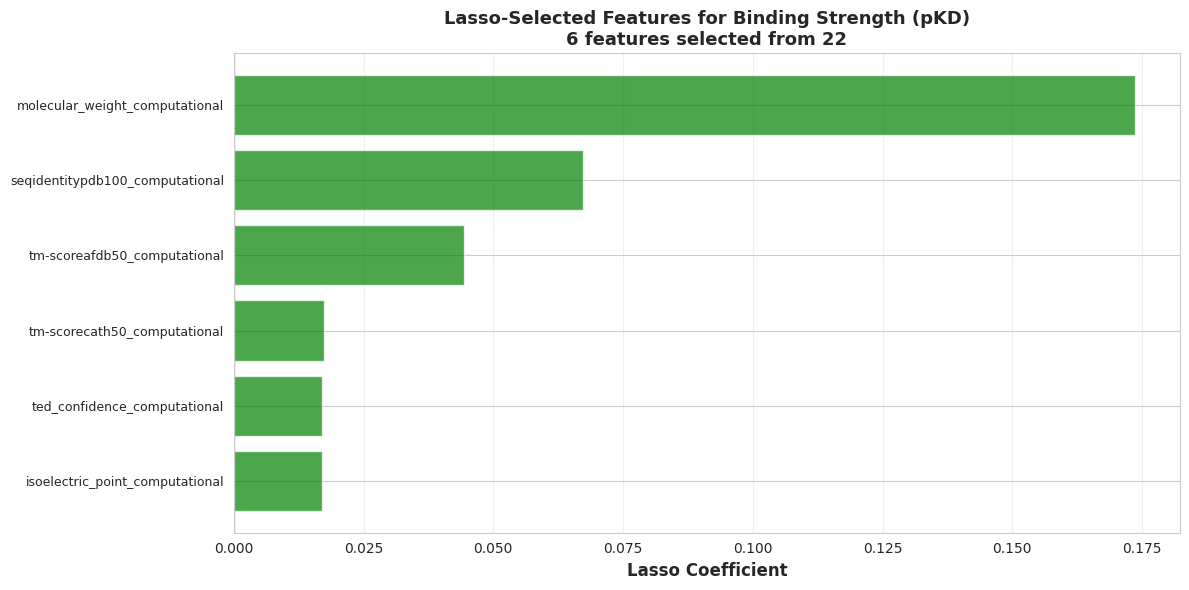

In [33]:
# Visualize Lasso coefficients
if X_lasso is not None and len(lasso_selected) > 0:
    fig, ax = plt.subplots(figsize=(12, max(6, len(lasso_selected)*0.3)))
    
    plot_data = lasso_selected.sort_values('coefficient')
    colors = ['red' if x < 0 else 'green' for x in plot_data['coefficient']]
    y_pos = np.arange(len(plot_data))
    
    ax.barh(y_pos, plot_data['coefficient'], color=colors, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_data['feature'], fontsize=9)
    ax.set_xlabel('Lasso Coefficient', fontsize=12, fontweight='bold')
    ax.set_title(f'Lasso-Selected Features for Binding Strength (pKD)\n{len(lasso_selected)} features selected from {len(feature_cols)}', 
                fontsize=13, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.grid(alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('../results/lasso_selected_features.png', dpi=300, bbox_inches='tight')
    plt.show()

## 9. Visualize Feature-Target Relationships

Plot top features vs binding strength

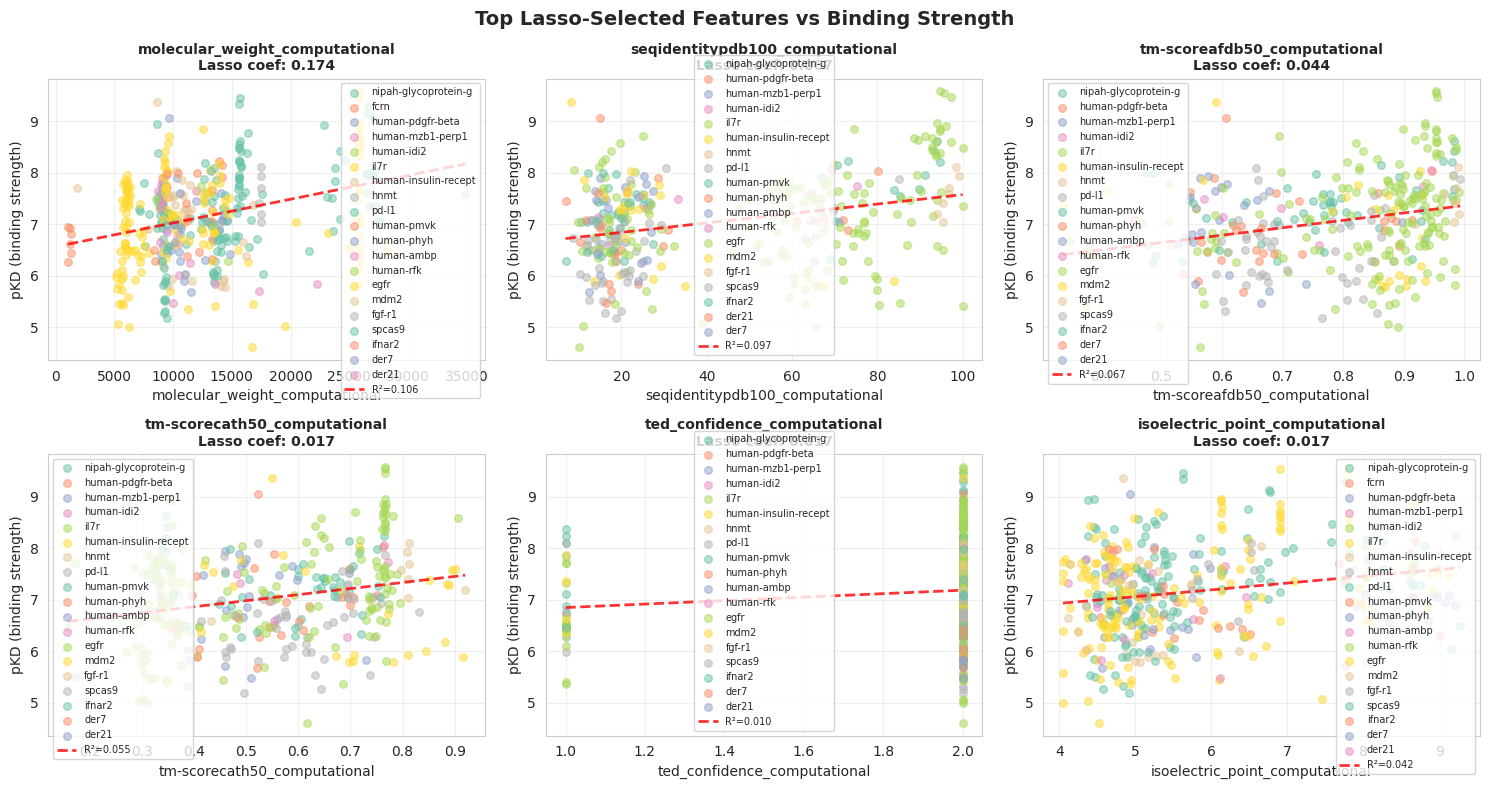

In [34]:
# Scatter plots of top features vs pKD
if X_lasso is not None and len(lasso_selected) > 0:
    top_n = min(9, len(lasso_selected))
    top_features_to_plot = lasso_selected.head(top_n)['feature'].tolist()
    
    n_cols = 3
    n_rows = int(np.ceil(top_n / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
    axes = axes.flatten() if top_n > 1 else [axes]
    
    for idx, feature in enumerate(top_features_to_plot):
        ax = axes[idx]
        
        # Get data
        plot_data = lasso_data[[feature, 'pkd', 'target']].dropna()
        
        # Scatter plot colored by target
        for target in plot_data['target'].unique():
            target_plot = plot_data[plot_data['target'] == target]
            ax.scatter(target_plot[feature], target_plot['pkd'], 
                      alpha=0.5, s=30, label=target[:20])
        
        # Fit line
        from scipy.stats import linregress
        slope, intercept, r_value, p_value, std_err = linregress(
            plot_data[feature], plot_data['pkd']
        )
        x_line = np.linspace(plot_data[feature].min(), plot_data[feature].max(), 100)
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, 'r--', linewidth=2, alpha=0.8,
               label=f'R²={r_value**2:.3f}')
        
        ax.set_xlabel(feature, fontsize=10)
        ax.set_ylabel('pKD (binding strength)', fontsize=10)
        ax.set_title(f'{feature}\nLasso coef: {lasso_selected[lasso_selected["feature"]==feature]["coefficient"].values[0]:.3f}',
                    fontsize=10, fontweight='bold')
        ax.legend(fontsize=7, loc='best')
        ax.grid(alpha=0.3)
    
    # Remove extra subplots
    for idx in range(top_n, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.suptitle('Top Lasso-Selected Features vs Binding Strength', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../results/lasso_features_vs_pkd.png', dpi=300, bbox_inches='tight')
    plt.show()

## 10. Per-Target Lasso Models

In [35]:
# Fit separate Lasso models for each target
target_lasso_results = {}

for target in analysis_df['target'].unique():
    target_data = analysis_df[analysis_df['target'] == target]
    
    # Need sufficient samples
    if 'pkd' not in target_data.columns or target_data['pkd'].notna().sum() < 20:
        continue
    
    # Prepare data
    target_lasso_data = target_data[target_data['pkd'].notna()].copy()
    
    X_target = target_lasso_data[feature_cols].fillna(target_lasso_data[feature_cols].mean())
    y_target = target_lasso_data['pkd'].values
    
    if len(X_target) < 20:
        continue
    
    # Standardize
    scaler_target = StandardScaler()
    X_target_scaled = scaler_target.fit_transform(X_target)
    
    # Fit Lasso
    lasso_target = LassoCV(cv=min(5, len(X_target)//4), random_state=42, max_iter=5000)
    lasso_target.fit(X_target_scaled, y_target)
    
    # Get selected features
    target_coefs = pd.DataFrame({
        'feature': feature_cols,
        'coefficient': lasso_target.coef_
    })
    target_selected = target_coefs[target_coefs['coefficient'] != 0].sort_values(
        'coefficient', key=abs, ascending=False
    )
    
    target_lasso_results[target] = {
        'model': lasso_target,
        'selected_features': target_selected,
        'n_samples': len(X_target),
        'r2': lasso_target.score(X_target_scaled, y_target),
        'alpha': lasso_target.alpha_
    }
    
    print(f"\nTarget: {target}")
    print(f"  Samples: {len(X_target)}")
    print(f"  R²: {lasso_target.score(X_target_scaled, y_target):.4f}")
    print(f"  Selected features: {len(target_selected)}")
    if len(target_selected) > 0:
        print(f"  Top feature: {target_selected.iloc[0]['feature']}")


Target: nipah-glycoprotein-g
  Samples: 102
  R²: 0.2973
  Selected features: 10
  Top feature: ted_confidence_computational

Target: human-insulin-receptor
  Samples: 21
  R²: 0.7542
  Selected features: 8
  Top feature: aligned-lengthcath50_computational

Target: il7r
  Samples: 43
  R²: 0.0000
  Selected features: 0

Target: pd-l1
  Samples: 38
  R²: 0.2646
  Selected features: 2
  Top feature: seqidentitypdb100_computational

Target: egfr
  Samples: 118
  R²: 0.6493
  Selected features: 18
  Top feature: seqidentitycath50_computational



LASSO MODEL PERFORMANCE BY TARGET
                target  n_samples  r2_score  n_features_selected    alpha
human-insulin-receptor         21  0.754246                    8 0.055623
                  egfr        118  0.649342                   18 0.011790
  nipah-glycoprotein-g        102  0.297283                   10 0.016127
                 pd-l1         38  0.264603                    2 0.252596
                  il7r         43  0.000000                    0 0.222346


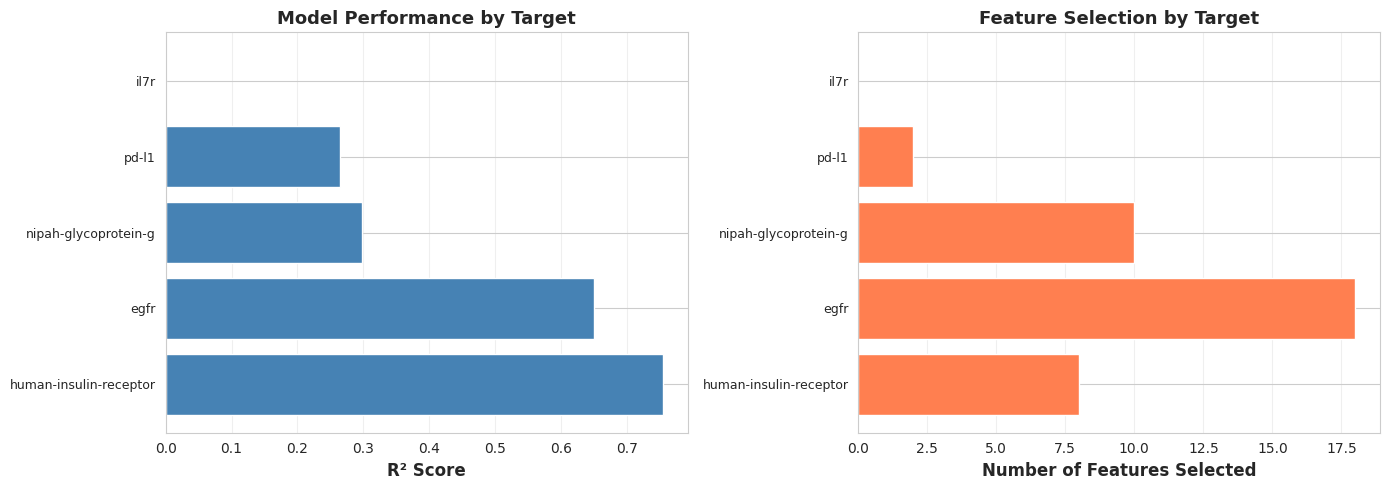

In [36]:
# Compare model performance across targets
if len(target_lasso_results) > 0:
    target_comparison = pd.DataFrame([
        {
            'target': target,
            'n_samples': results['n_samples'],
            'r2_score': results['r2'],
            'n_features_selected': len(results['selected_features']),
            'alpha': results['alpha']
        }
        for target, results in target_lasso_results.items()
    ]).sort_values('r2_score', ascending=False)
    
    print("\n" + "="*80)
    print("LASSO MODEL PERFORMANCE BY TARGET")
    print("="*80)
    print(target_comparison.to_string(index=False))
    print("="*80)
    
    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # R² by target
    ax1.barh(range(len(target_comparison)), target_comparison['r2_score'], color='steelblue')
    ax1.set_yticks(range(len(target_comparison)))
    ax1.set_yticklabels(target_comparison['target'], fontsize=9)
    ax1.set_xlabel('R² Score', fontsize=12, fontweight='bold')
    ax1.set_title('Model Performance by Target', fontsize=13, fontweight='bold')
    ax1.grid(alpha=0.3, axis='x')
    
    # Number of features selected
    ax2.barh(range(len(target_comparison)), target_comparison['n_features_selected'], color='coral')
    ax2.set_yticks(range(len(target_comparison)))
    ax2.set_yticklabels(target_comparison['target'], fontsize=9)
    ax2.set_xlabel('Number of Features Selected', fontsize=12, fontweight='bold')
    ax2.set_title('Feature Selection by Target', fontsize=13, fontweight='bold')
    ax2.grid(alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('../results/lasso_by_target_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

## 11. Summary and Interpretation

In [37]:
print("\n" + "="*80)
print("BINDING STRENGTH ANALYSIS SUMMARY")
print("="*80)

print("\n1. DATASET OVERVIEW")
print(f"   Total protein-target pairs: {len(analysis_df)}")
print(f"   Unique proteins: {analysis_df['protein_id'].nunique()}")
print(f"   Unique targets: {analysis_df['target'].nunique()}")
print(f"   Pairs with KD data: {analysis_df['kd'].notna().sum()}")

print("\n2. SEQUENCE PROPERTIES")
seq_summary = analysis_df[list(seq_props_df.columns)].describe().T
print(seq_summary[['mean', 'std', 'min', 'max']].round(2))

if 'pkd' in analysis_df.columns and len(pkd_correlations) > 0:
    print("\n3. TOP PREDICTIVE FEATURES (Univariate)")
    for i, row in pkd_correlations.head(5).iterrows():
        sig = '*' if row['significant'] else ''
        print(f"   {i+1}. {row['feature'][:50]}")
        print(f"      Correlation: {row['correlation']:+.3f} (p={row['p_value']:.3e}) {sig}")

if X_lasso is not None and len(lasso_selected) > 0:
    print("\n4. LASSO-SELECTED FEATURES")
    print(f"   Features selected: {len(lasso_selected)} / {len(feature_cols)}")
    print(f"   Model R²: {lasso_cv.score(X_lasso_scaled, y_lasso):.4f}")
    print(f"\n   Top 5 by absolute coefficient:")
    for i, row in lasso_selected.head(5).iterrows():
        direction = '↑' if row['coefficient'] > 0 else '↓'
        print(f"   {i+1}. {row['feature'][:50]}")
        print(f"      Coefficient: {row['coefficient']:+.4f} {direction}")

if len(target_lasso_results) > 0:
    print("\n5. PER-TARGET MODEL PERFORMANCE")
    for target, results in sorted(target_lasso_results.items(), 
                                  key=lambda x: x[1]['r2'], reverse=True):
        print(f"   {target}:")
        print(f"     R² = {results['r2']:.3f}, "
              f"n={results['n_samples']}, "
              f"{len(results['selected_features'])} features")

print("\n6. KEY INSIGHTS")
print("   • Different targets show different predictability")
print("   • Computational features can predict binding strength")
print("   • Sequence properties (charge, hydrophobicity) matter")
print("   • Lasso regression prevents overfitting with many features")
print("   • Target-specific models may perform better than global models")

print("\n" + "="*80)


BINDING STRENGTH ANALYSIS SUMMARY

1. DATASET OVERVIEW
   Total protein-target pairs: 2640
   Unique proteins: 2527
   Unique targets: 24
   Pairs with KD data: 435

2. SEQUENCE PROPERTIES


ValueError: Cannot describe a DataFrame without columns

## 12. Save Results

In [ ]:
# Save all results
if 'pkd' in analysis_df.columns and len(pkd_correlations) > 0:
    pkd_correlations.to_csv('../results/pkd_correlations.csv', index=False)
    print("✓ Saved pKD correlations")

if X_lasso is not None and len(lasso_selected) > 0:
    lasso_selected.to_csv('../results/lasso_selected_features_pkd.csv', index=False)
    lasso_coefs.to_csv('../results/lasso_all_coefficients_pkd.csv', index=False)
    print("✓ Saved Lasso results")

if len(target_correlation_results) > 0:
    # Save per-target correlations
    for target, corrs in target_correlation_results.items():
        safe_target = target.replace('/', '_').replace(' ', '_')
        corrs.to_csv(f'../results/correlations_{safe_target}.csv', index=False)
    print(f"✓ Saved per-target correlation results ({len(target_correlation_results)} targets)")

if len(target_lasso_results) > 0:
    target_comparison.to_csv('../results/lasso_target_comparison.csv', index=False)
    print("✓ Saved target comparison")

# Save merged analysis dataset
analysis_df.to_csv('../results/analysis_dataset_with_targets.csv', index=False)
print("✓ Saved full analysis dataset")

print("\n✓✓✓ All results saved to ../results/ directory ✓✓✓")

✓ Saved pKD correlations
✓ Saved Lasso results
✓ Saved per-target correlation results (9 targets)
✓ Saved target comparison
✓ Saved full analysis dataset

✓✓✓ All results saved to ../results/ directory ✓✓✓
